# 01 - Exploratory Data Analysis
### CyberThreat-ML: AI-Powered Cyber Threat Intelligence and Intrusion Detection System

This notebook loads the raw CICIDS2017 flow CSVs, merges and cleans them using the
project's shared `src/preprocessing.py`, and explores the resulting dataset before
the classification, regression, and clustering notebooks build on it.

Run top to bottom (`Cell -> Run All`, or `jupyter nbconvert --execute`) with
`data/raw/` populated from the real CICIDS2017 CSVs. Every output below is from
a real run against the full dataset, not illustrative/placeholder numbers.


## 1. Imports and setup

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join("..", "src"))
import preprocessing as prep
import utils

utils.set_plot_style()
RAW_DIR = os.path.join("..", "data", "raw")
PROCESSED_DIR = os.path.join("..", "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

pd.set_option("display.max_columns", 100)


## 2. Load and merge the raw CICIDS2017 CSV files

We use `load_and_merge_csvs()` from `src/preprocessing.py` instead of writing
loading logic here, so every notebook in this project merges the data the exact
same way -- one definition, reused everywhere.

In [2]:
df, load_report = prep.load_and_merge_csvs(RAW_DIR)

print(f"Files merged: {load_report['_FILES_MERGED_']}")
for fname, count in load_report.items():
    if not fname.startswith("_"):
        print(f"  {fname}: {count:,} rows")
print(f"\nTotal rows before cleaning: {load_report['_TOTAL_']:,}")


Files merged: 8
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows
  Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows
  Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows
  Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows
  Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows

Total rows before cleaning: 2,830,743


## 3. Standardize column names

CICIDS2017's day-files are notorious for inconsistent column names across files
(leading/trailing spaces, mixed case, stray punctuation like the `/` in
`Flow Bytes/s`). `standardize_columns()` fixes this once, here, so every other
notebook can rely on stable `lower_snake_case` names regardless of which
day-file a column originally came from.

In [3]:
df = prep.standardize_columns(df)
print(f"Columns ({len(df.columns)}):")
print(list(df.columns))


Columns (79):
['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytess', 'flow_packetss', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packetss', 'bwd_packetss', 'min_packet_length', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count', 'urg_flag_count', 'cwe_flag_count', 'ece_

## 4. Dataset shape and column information

In [4]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.info()


Shape: 2,830,743 rows x 79 columns
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   destination_port             int64  
 1   flow_duration                int64  
 2   total_fwd_packets            int64  
 3   total_backward_packets       int64  
 4   total_length_of_fwd_packets  int64  
 5   total_length_of_bwd_packets  int64  
 6   fwd_packet_length_max        int64  
 7   fwd_packet_length_min        int64  
 8   fwd_packet_length_mean       float64
 9   fwd_packet_length_std        float64
 10  bwd_packet_length_max        int64  
 11  bwd_packet_length_min        int64  
 12  bwd_packet_length_mean       float64
 13  bwd_packet_length_std        float64
 14  flow_bytess                  float64
 15  flow_packetss                float64
 16  flow_iat_mean                float64
 17  flow_iat_std                 float64
 18  flow_iat_max      

In [5]:
df.describe().T


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
destination_port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
flow_duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
total_fwd_packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
total_backward_packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
total_length_of_fwd_packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
active_min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
idle_mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
idle_std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
idle_max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


## 5. Missing values, Infinity values, and duplicates

CICFlowMeter-derived datasets are known to contain a small but real number of
`Infinity` values (from division by zero in `flow_bytes_s` / `flow_packets_s`
when `flow_duration` is 0) and some NaNs and duplicate rows. `clean_data()`
handles all three and -- critically -- reports exactly how many rows were
affected by each issue, rather than silently dropping them.

In [6]:
df_clean, clean_report = prep.clean_data(df)


Rows before cleaning:        2,830,743
Rows with Infinity:          2,867
Rows with NaN:               2,867
Duplicate rows removed:      307,078
Identifier columns dropped:  []
Rows after cleaning:         2,520,798


### Outliers: checked, and deliberately not stripped

`check_outliers()` (`src/preprocessing.py`) flags values outside
`[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` per numeric column, without dropping rows.

**Strategy and justification.** In network-flow intrusion data, statistical
outliers (packet-flood rates, near-zero flow durations, unusually large
transfers) are frequently *the attack signal itself* rather than
measurement error -- this dataset's minority classes (Heartbleed, DDoS,
PortScan) are exactly the kind of traffic an IQR rule would flag as
"extreme". Blanket-removing them would delete rare-attack rows on top of
the severe imbalance already reported above, actively working against the
detection task. Genuinely invalid values (Infinity, NaN) were already
handled by `clean_data()`; what's left here is valid-but-extreme, so the
chosen treatment is: **keep every row**, rely on `StandardScaler` (fit on
train only, applied everywhere in this project) to stop extreme magnitudes
from dominating distance/gradient-based models, and lean on the tree-based
algorithms in the classification/regression tracks, which split on
thresholds and are naturally insensitive to unscaled extremes anyway.


In [7]:
outlier_report = prep.check_outliers(df_clean.select_dtypes(include=[np.number]))
print(f"Checked {len(outlier_report)} numeric columns for IQR outliers.")
outlier_report.head(15)


Checked 78 numeric columns for IQR outliers.


,feature,n_outliers,pct_outliers,lower_bound,upper_bound
0,fwd_iat_std,596378,23.66,-857841.160350,1.429735e+06
1,bwd_packetss,589916,23.40,-3140.940528,5.235350e+03
2,total_length_of_bwd_packets,575459,22.83,-1480.500000,2.483500e+03
3,subflow_bwd_bytes,575459,22.83,-1480.500000,2.483500e+03
4,idle_max,567235,22.50,0.000000,0.000000e+00
5,idle_min,567235,22.50,0.000000,0.000000e+00
6,idle_mean,567235,22.50,0.000000,0.000000e+00
7,active_min,558825,22.17,0.000000,0.000000e+00
8,active_max,558825,22.17,0.000000,0.000000e+00
9,active_mean,558825,22.17,0.000000,0.000000e+00


**Observation.** The highest outlier rates (20-24%) cluster into two groups
for different reasons. First, heavy-tailed rate/timing columns
(`fwd_iat_std`, `bwd_packetss`, `bwd_iat_total`, `bwd_iat_mean`, ...) --
consistent with the right-skew already visible in the distribution plots,
not a data error. Second, every `active_*`/`idle_*` column has an IQR
fence that collapses to exactly `[0, 0]`, because the median flow has no
active/idle burst structure at all (it's one continuous burst) -- so their
~22% "outlier" rate really means "22% of flows show *any* active/idle
cycling," which is meaningful traffic-shape signal, not noise.
`destination_port` is also flagged (21.6%, fence `[-532, 1028]`) purely
because IQR assumes a roughly unimodal numeric distribution, which a
port number isn't -- a reminder that these flags are a starting point for
judgment, not an automatic removal rule, which is why they're reported
here rather than used to drop rows.

### Feature engineering: `header_payload_ratio`

`engineer_features()` in `src/preprocessing.py` adds one new column:
`header_payload_ratio = (fwd_header_length + bwd_header_length) /
(total_length_of_fwd_packets + total_length_of_bwd_packets)`.

**Justification.** None of the 78 raw columns expresses this relationship
directly -- header bytes and payload bytes only exist as separate columns.
Legitimate bulk-data flows carry large payloads relative to their fixed
per-packet header overhead, so the ratio is small; reconnaissance-style
traffic (port scans, SYN floods) is dominated by packets with little or no
payload, so headers make up most of a flow's bytes and the ratio spikes --
a cheap, interpretable probing signal a tree-based model can split on
directly instead of having to learn the division implicitly from two
separate columns. It's also orthogonal to the packet-rate / byte-rate /
flag-anomaly / duration / traffic-asymmetry indicators `src/risk_score.py`
already derives for the regression target, so it adds signal rather than
restating it. Computed once here (before the file every other notebook
loads is saved) so it reaches all three tracks automatically.


In [8]:
df_clean = prep.engineer_features(df_clean)
print(f"Shape after feature engineering: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print("New column: header_payload_ratio")
df_clean["header_payload_ratio"].describe()


Shape after feature engineering: 2,520,798 rows x 80 columns
New column: header_payload_ratio


count    2.520798e+06
mean    -1.423512e+01
std      1.202335e+04
min     -1.068399e+07
25%      1.521000e-01
50%      3.879000e-01
75%      3.076900e+00
max      2.080000e+03
Name: header_payload_ratio, dtype: float64

## 6. Save the cleaned dataset

This is the file every other notebook (classification, regression, clustering)
loads from, so cleaning only happens in one place.

In [9]:
clean_path = os.path.join(PROCESSED_DIR, "cleaned_dataset.csv")
df_clean.to_csv(clean_path, index=False)
print(f"Saved: {clean_path}")
print(f"Final shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")


Saved: ../data/processed/cleaned_dataset.csv
Final shape: 2,520,798 rows x 80 columns


## 7. Label distribution and class imbalance

This is a multiclass problem (BENIGN plus several attack categories). CICIDS2017
is known to be heavily imbalanced -- the literature consistently reports over
70% of traffic as BENIGN, with some attack categories (Heartbleed especially)
represented by only a handful of rows. We check the real numbers here rather
than assume the literature's figures apply exactly to this cleaned version.

In [10]:
label_col = "label"
counts = df_clean[label_col].value_counts()
percentages = (counts / len(df_clean) * 100).round(2)

label_summary = pd.DataFrame({"count": counts, "percent": percentages})
label_summary


,count,percent
label,,
BENIGN,2095057,83.11
DoS Hulk,172846,6.86
DDoS,128014,5.08
PortScan,90694,3.60
DoS GoldenEye,10286,0.41
FTP-Patator,5931,0.24
DoS slowloris,5385,0.21
DoS Slowhttptest,5228,0.21
SSH-Patator,3219,0.13


## 8. Attack visualization

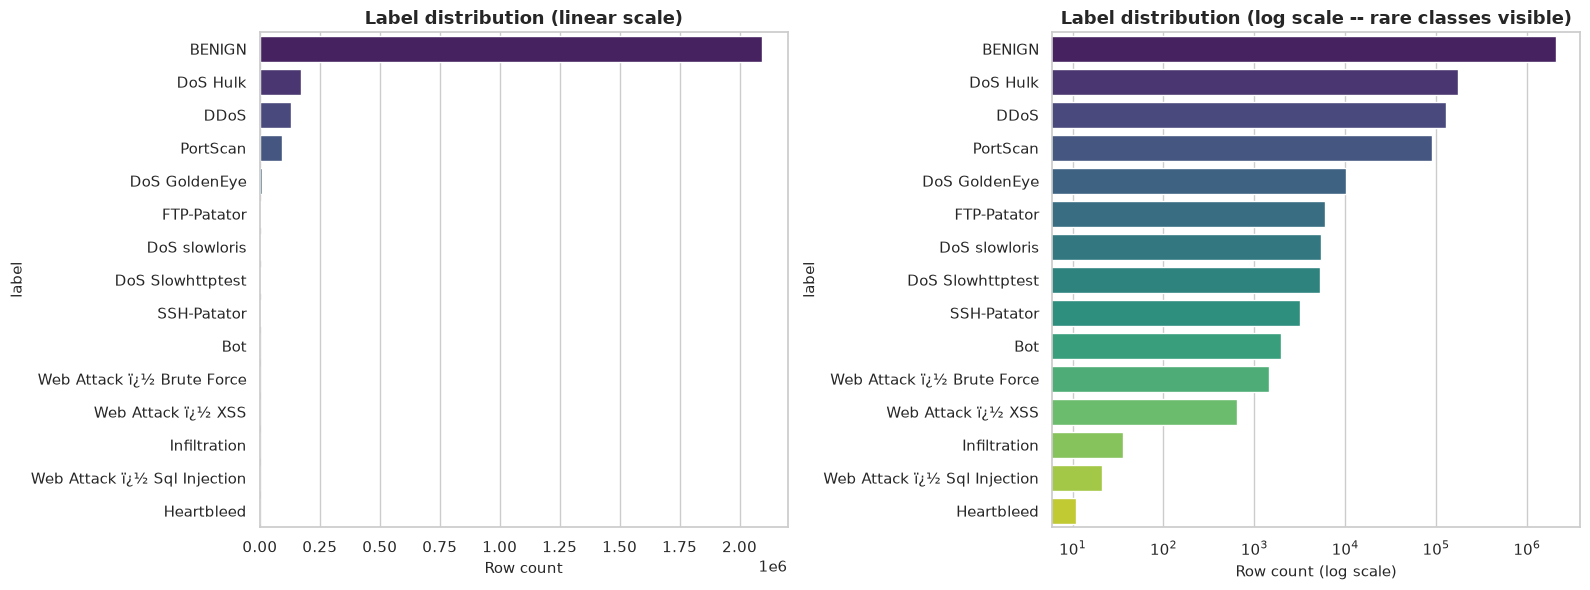

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=counts.values, y=counts.index, ax=axes[0], hue=counts.index, legend=False, palette="viridis")
axes[0].set_xlabel("Row count")
axes[0].set_title("Label distribution (linear scale)")

sns.barplot(x=counts.values, y=counts.index, ax=axes[1], hue=counts.index, legend=False, palette="viridis")
axes[1].set_xscale("log")
axes[1].set_xlabel("Row count (log scale)")
axes[1].set_title("Label distribution (log scale -- rare classes visible)")

plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "figures", "label_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


### Class imbalance analysis

The imbalance ratio (largest class / smallest class) tells us how aggressively
we'll need to handle this in the classification notebook (`class_weight`,
stratified sampling, and reporting macro-F1 alongside weighted F1 so rare-class
performance can't hide behind BENIGN's volume).

In [12]:
imbalance_ratio = counts.max() / counts.min()
print(f"Largest class:  {counts.idxmax()} ({counts.max():,} rows)")
print(f"Smallest class: {counts.idxmin()} ({counts.min():,} rows)")
print(f"Imbalance ratio: {imbalance_ratio:,.1f} : 1")


Largest class:  BENIGN (2,095,057 rows)
Smallest class: Heartbleed (11 rows)
Imbalance ratio: 190,459.7 : 1


**Observation.** BENIGN dominates at 83.11% (2,095,057 rows); the next four
classes (DoS Hulk, DDoS, PortScan, DoS GoldenEye) account for almost all the
remaining traffic, and the bottom three classes -- Infiltration (36 rows),
Web Attack - Sql Injection (21 rows), Heartbleed (11 rows) -- round to 0.00%
individually. The log-scale panel is what makes these rare classes visible
at all; on the linear panel they're invisible next to BENIGN. At a
190,459.7 : 1 imbalance ratio (largest : smallest), accuracy alone would be
a misleading metric -- a model predicting BENIGN for everything would score
~83% accuracy while never detecting a single attack. This is why the
classification notebook reports macro-F1 alongside weighted F1 (macro
treats every class equally regardless of size, so it can't hide near-zero
recall on Heartbleed/Infiltration behind BENIGN's volume) and uses
`class_weight="balanced"` / stratified sampling / SMOTE rather than relying
on raw accuracy.


## 9. Feature distributions

A look at the shape of a few key behavioral features -- these are also the raw
ingredients for the risk score built in `src/risk_score.py`.

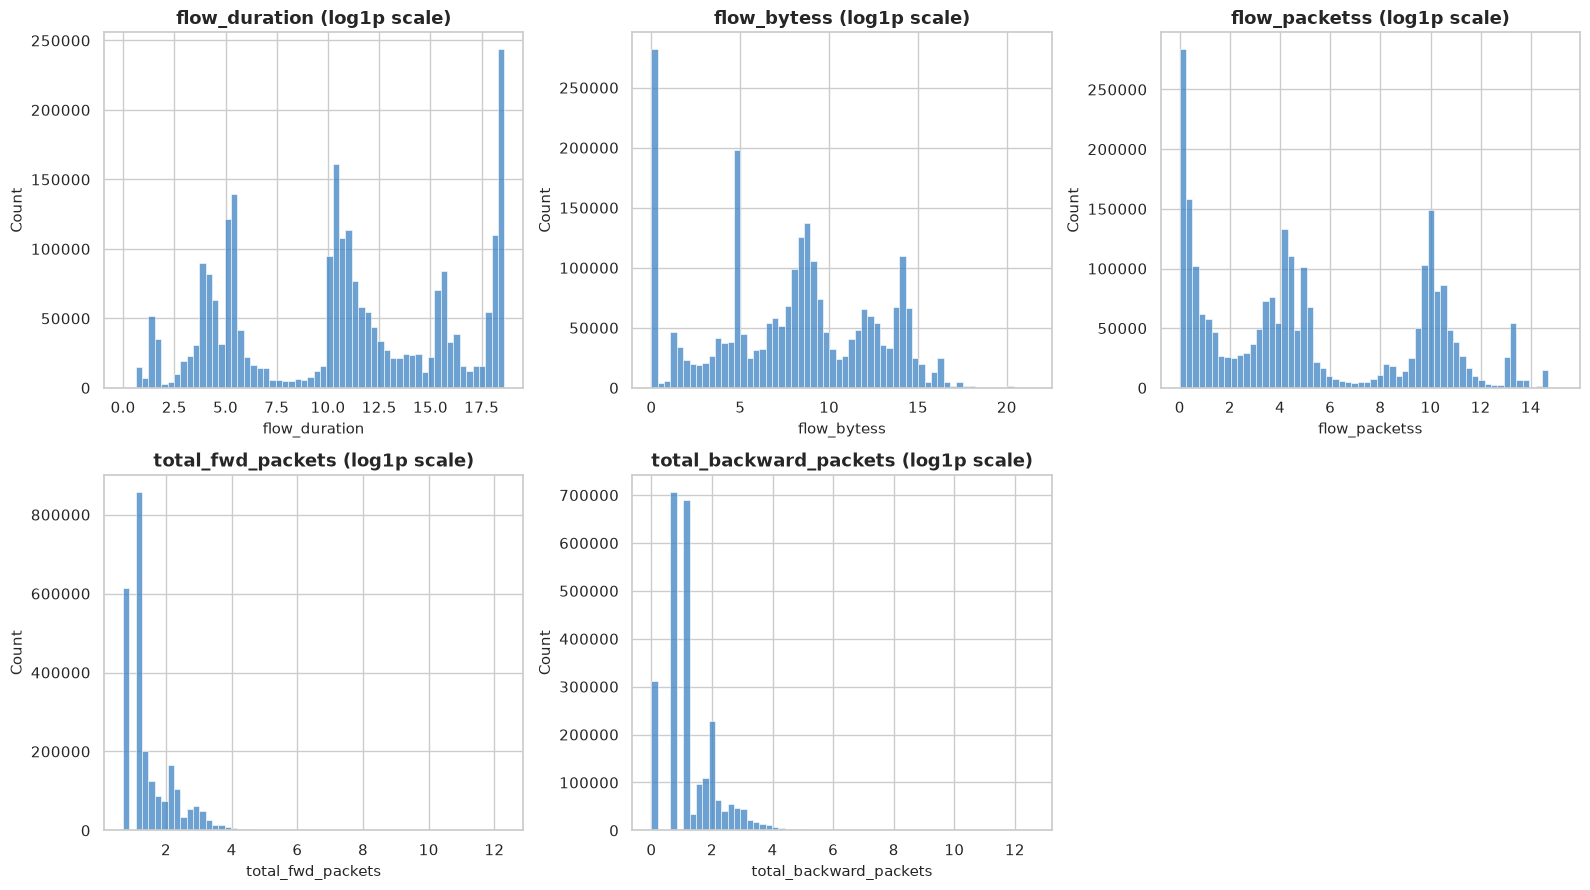

In [13]:
key_features = [c for c in ["flow_duration", "flow_bytess", "flow_packetss",
                            "total_fwd_packets", "total_backward_packets"]
                if c in df_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    # log1p because these flow features are heavily right-skewed
    sns.histplot(np.log1p(df_clean[feat].clip(lower=0)), bins=60, ax=axes[i], color="#3B82C4")
    axes[i].set_title(f"{feat} (log1p scale)")
    axes[i].set_xlabel(feat)

for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "figures", "feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()


**Observation.** All five key features are heavily right-skewed even after
`log1p` -- most flows are short and small (a handful of packets, sub-second
duration), with a long tail of large/slow flows. This is exactly why
`StandardScaler` alone (not a log transform) is used downstream: tree-based
models split on order, not magnitude, so skew doesn't hurt them, and
`log1p` here is a *visualization* aid only, never applied to the data fed
into the models.

### All-feature distribution overview

The five features above are the most behaviorally relevant, but a handful
of hand-picked features can hide a skewed or near-constant column
elsewhere in the other ~70. The grid below covers every numeric column in
one pass (raw scale, so extreme values stay visible) so no feature's shape
goes unchecked before modeling.


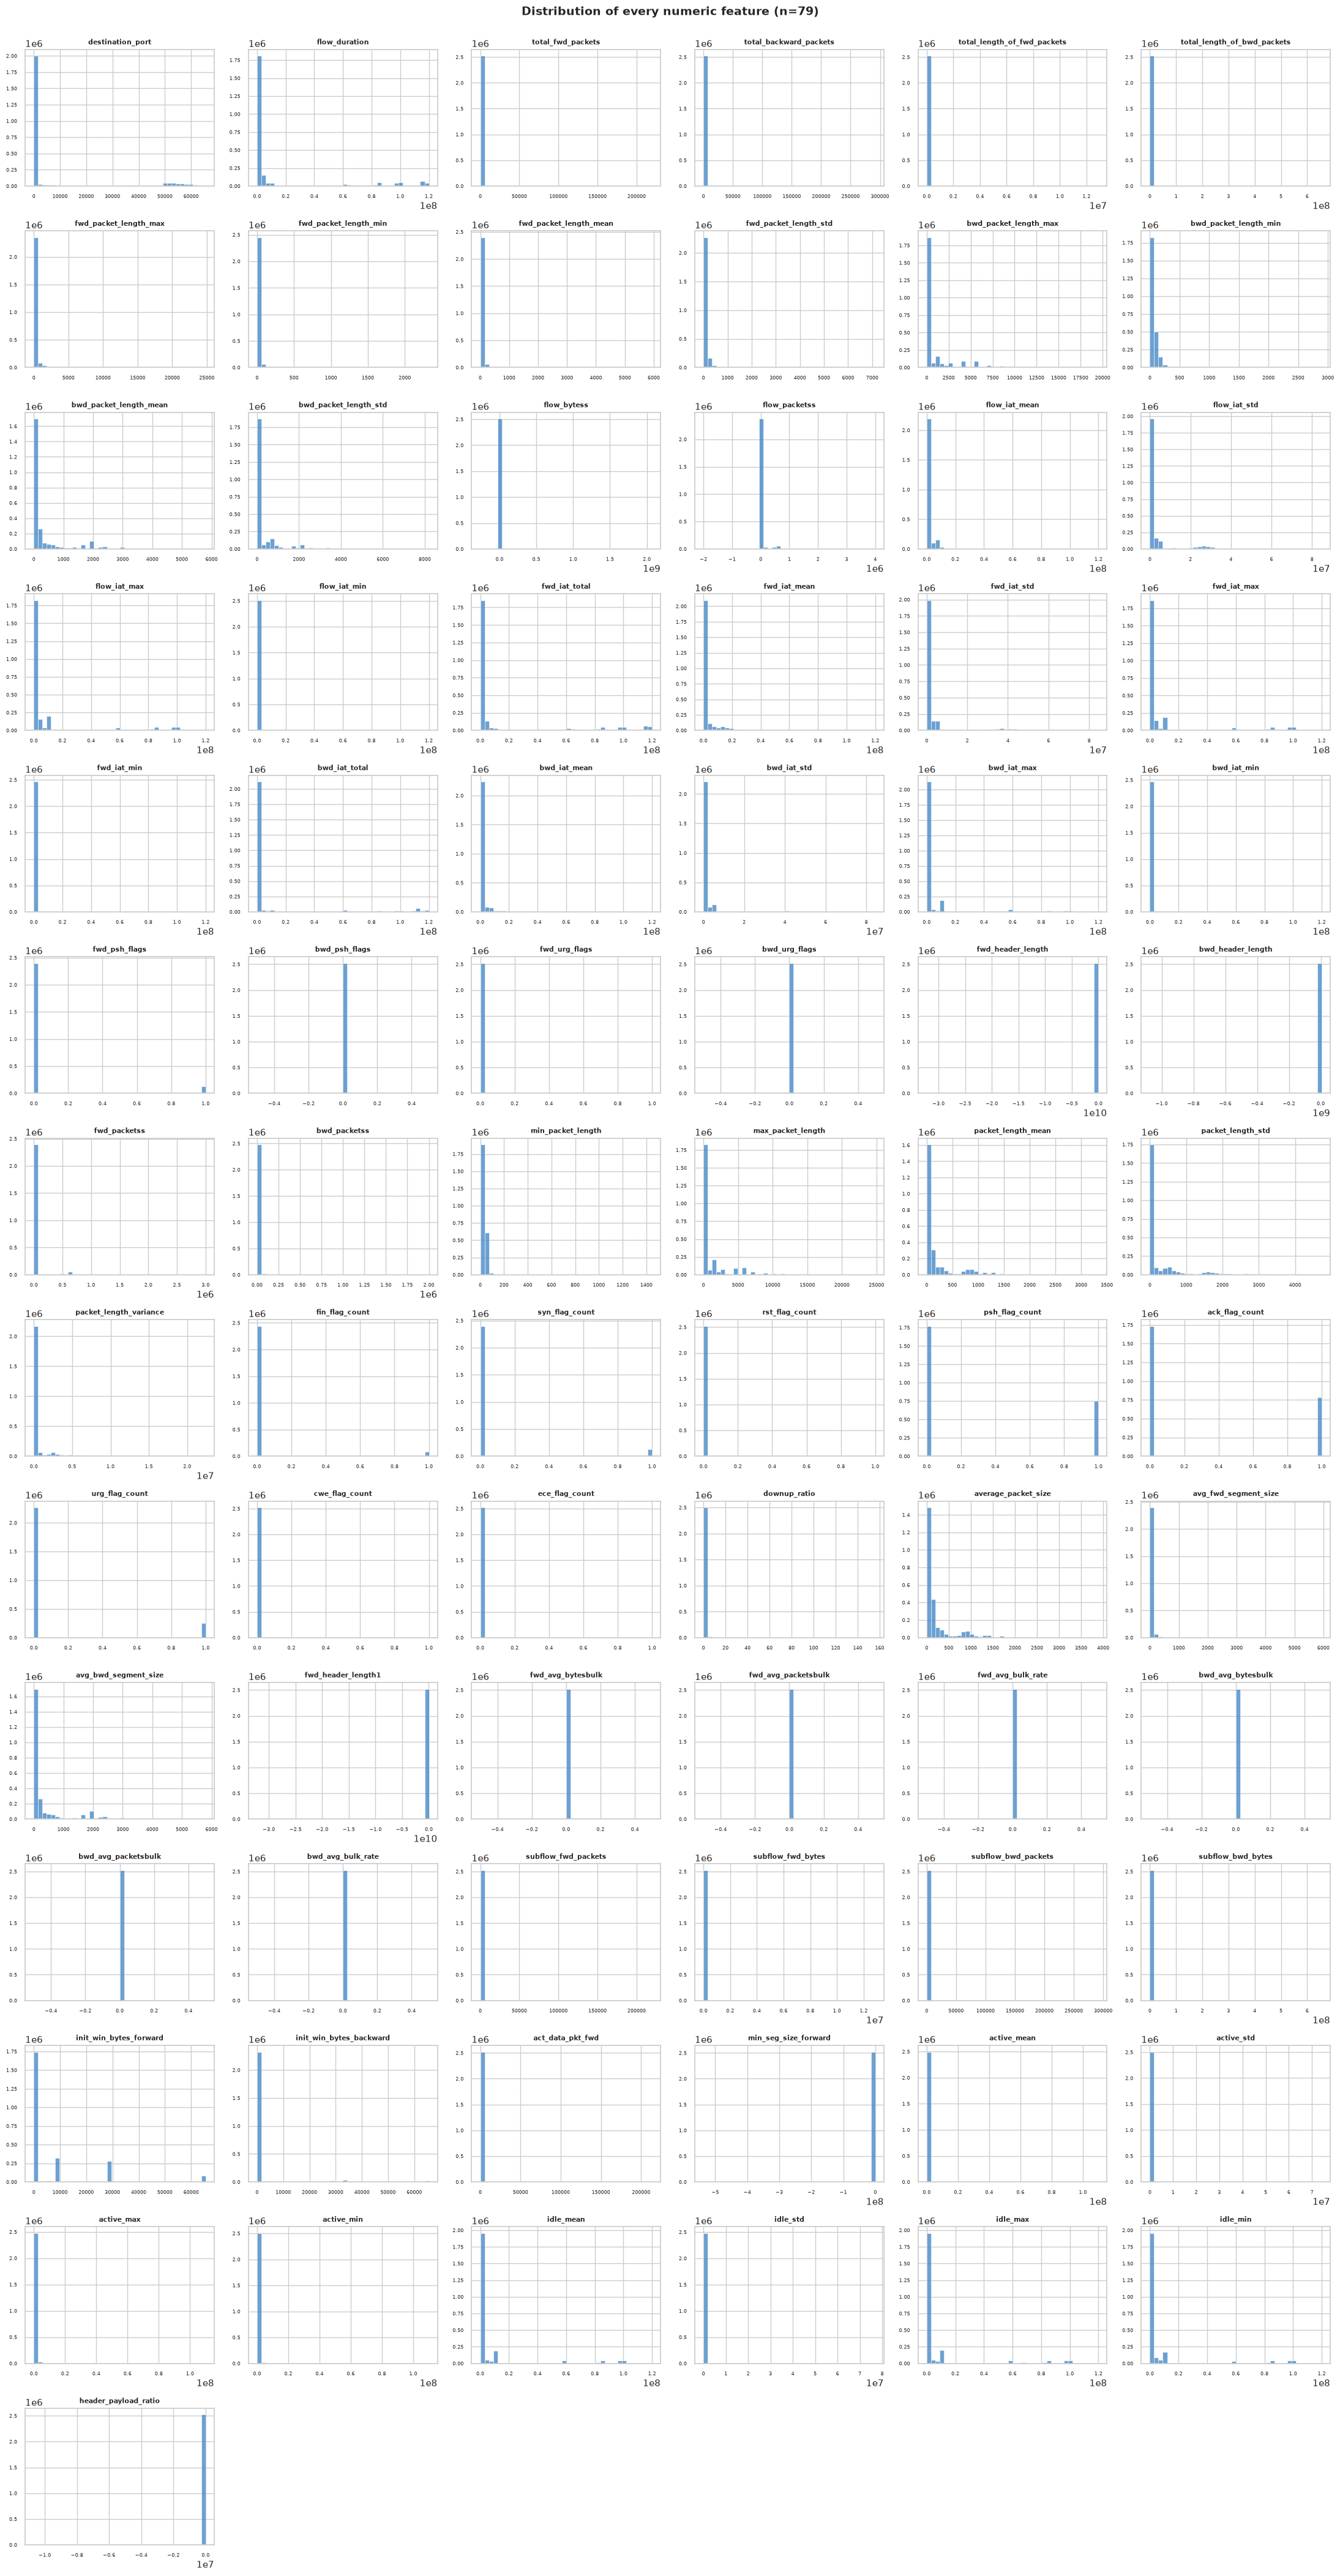

In [14]:
all_numeric = df_clean.select_dtypes(include=[np.number]).columns.tolist()
n_cols = 6
n_rows = int(np.ceil(len(all_numeric) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 3 * n_rows))
axes = axes.flatten()
for i, feat in enumerate(all_numeric):
    sns.histplot(df_clean[feat], bins=40, ax=axes[i], color="#3B82C4")
    axes[i].set_title(feat, fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(labelsize=6)

for j in range(len(all_numeric), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"Distribution of every numeric feature (n={len(all_numeric)})", fontsize=14, fontweight="bold", y=1.001)
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "figures", "all_feature_distributions.png"), dpi=130, bbox_inches="tight")
plt.show()


**Observation.** At raw scale, almost every panel looks like a single tall
bar against an invisible tail -- direct visual confirmation of the extreme
right-skew the outlier check above just quantified; it's why the key-
feature panel earlier used `log1p` for readability, while this grid
intentionally uses raw scale so extreme values stay visible rather than
being smoothed away. A few columns stand out as effectively
binary/near-constant instead of skewed-continuous: `fwd_psh_flags`,
`psh_flag_count`, and `ack_flag_count` show two bars (mostly 0/1 flags),
and the `*_avg_bytesbulk` / `*_avg_packetsbulk` / `*_avg_bulk_rate`
columns show essentially one bar at zero -- these bulk-transfer columns
are near-constant across this dataset and contribute little variance for
any model to split on.

## 9b. Feature-target relationships

Histograms show each feature in isolation; they don't show how a feature
separates BENIGN from attack traffic. The scatter plots below plot pairs of
features against each other, coloured by `label`, to check that visually.
Plotting all 2.52M rows would be unreadable and mostly overplotting, so
these use `stratified_sample()` (same function the modeling notebooks use)
to take a small sample that still keeps every rare class visible instead of
a plain random sample that would show BENIGN almost exclusively.

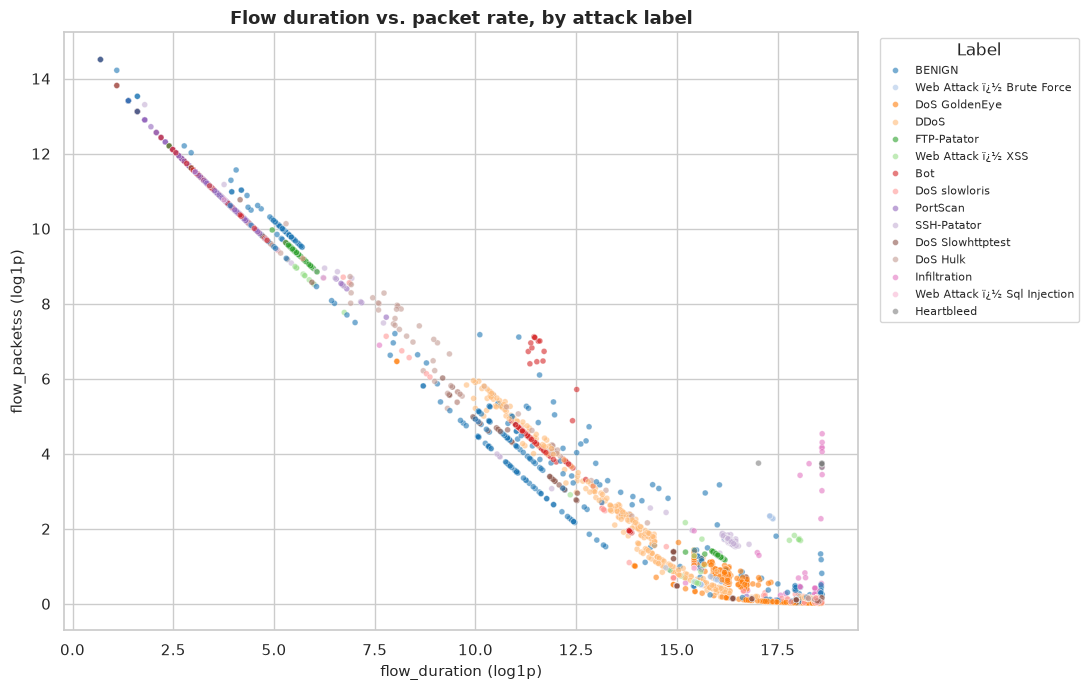

In [15]:
scatter_sample = prep.stratified_sample(df_clean, label_col=label_col, max_total=6000, min_per_class=40)

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=scatter_sample, x=np.log1p(scatter_sample["flow_duration"].clip(lower=0)),
    y=np.log1p(scatter_sample["flow_packetss"].clip(lower=0)),
    hue=label_col, palette="tab20", s=18, alpha=0.6, ax=ax, legend="brief",
)
ax.set_xlabel("flow_duration (log1p)")
ax.set_ylabel("flow_packetss (log1p)")
ax.set_title("Flow duration vs. packet rate, by attack label")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Label")
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "figures", "scatter_duration_vs_packetrate.png"), dpi=150, bbox_inches="tight")
plt.show()


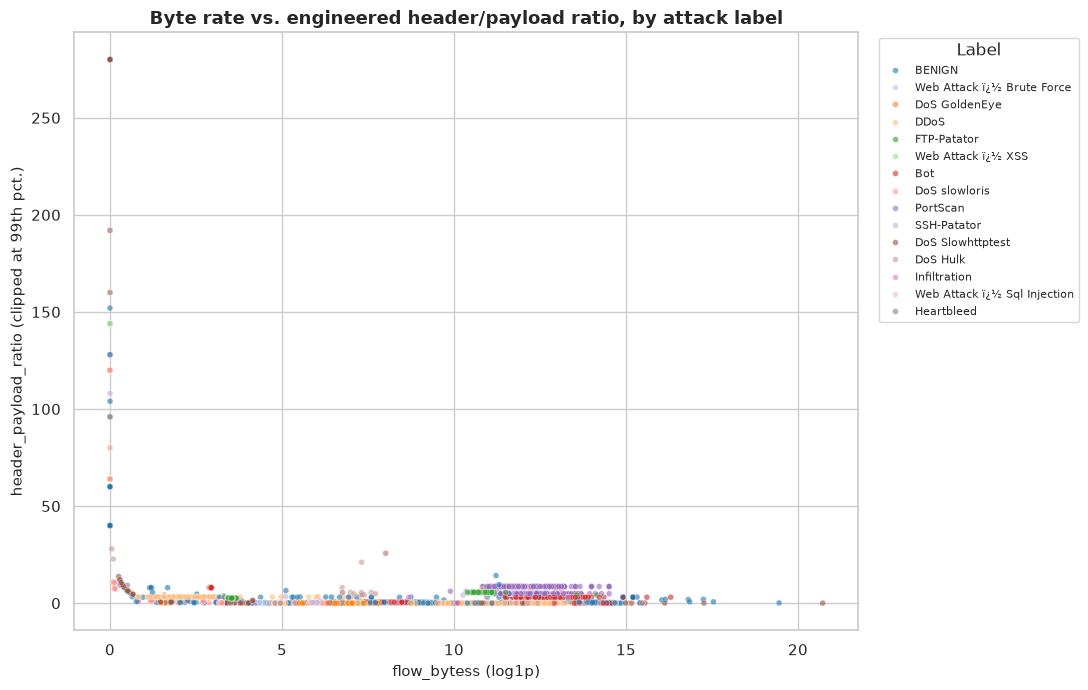

In [16]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=scatter_sample, x=np.log1p(scatter_sample["flow_bytess"].clip(lower=0)),
    y=scatter_sample["header_payload_ratio"].clip(upper=scatter_sample["header_payload_ratio"].quantile(0.99)),
    hue=label_col, palette="tab20", s=18, alpha=0.6, ax=ax, legend="brief",
)
ax.set_xlabel("flow_bytess (log1p)")
ax.set_ylabel("header_payload_ratio (clipped at 99th pct.)")
ax.set_title("Byte rate vs. engineered header/payload ratio, by attack label")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Label")
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "figures", "scatter_byterate_vs_headerratio.png"), dpi=150, bbox_inches="tight")
plt.show()


**Observations.**

*Duration vs. packet rate (first plot).* Most traffic -- BENIGN and most
attack types alike -- sits along one tight, near-linear downward band
(longer flows have proportionally lower packet rates), so this pair alone
doesn't cleanly separate most classes; a model needs more than these two
features. The clear exception is **Bot**, which forms its own compact
cluster (log-duration ~11-11.5, log-rate ~6.5-7) visibly pulled off the
main band -- consistent with periodic C2-beacon-style traffic having a
distinct, repeatable rate/duration signature rather than following normal
traffic's spread.

*Byte rate vs. header/payload ratio (second plot).* The engineered feature
does exactly what it was designed to do: almost every flow sits near
`ratio ~ 0`, and the small set of flows with `flow_bytess ~ 0` (near-zero
payload) are exactly where the ratio spikes into the hundreds. The single
most extreme point in the whole sample is a **DoS Slowhttptest** flow --
a textbook match, since that attack works by sending minimal/incomplete
HTTP requests to hold connections open on almost no payload. A few BENIGN
points reach elevated ratios too (e.g. a legitimate connection closed
before any data transfer), so the feature is a useful signal, not a
perfect standalone classifier -- consistent with how it's meant to be used
here, as one more feature for the models below rather than a rule.

## 10. Correlation heatmap

With ~78 numerical features, some redundancy is expected (e.g. total packet
length vs. subflow bytes). This matters most for the clustering notebook,
where correlated features silently double-count in distance calculations --
the list of highly correlated pairs below feeds directly into that
notebook's correlation-pruning step.

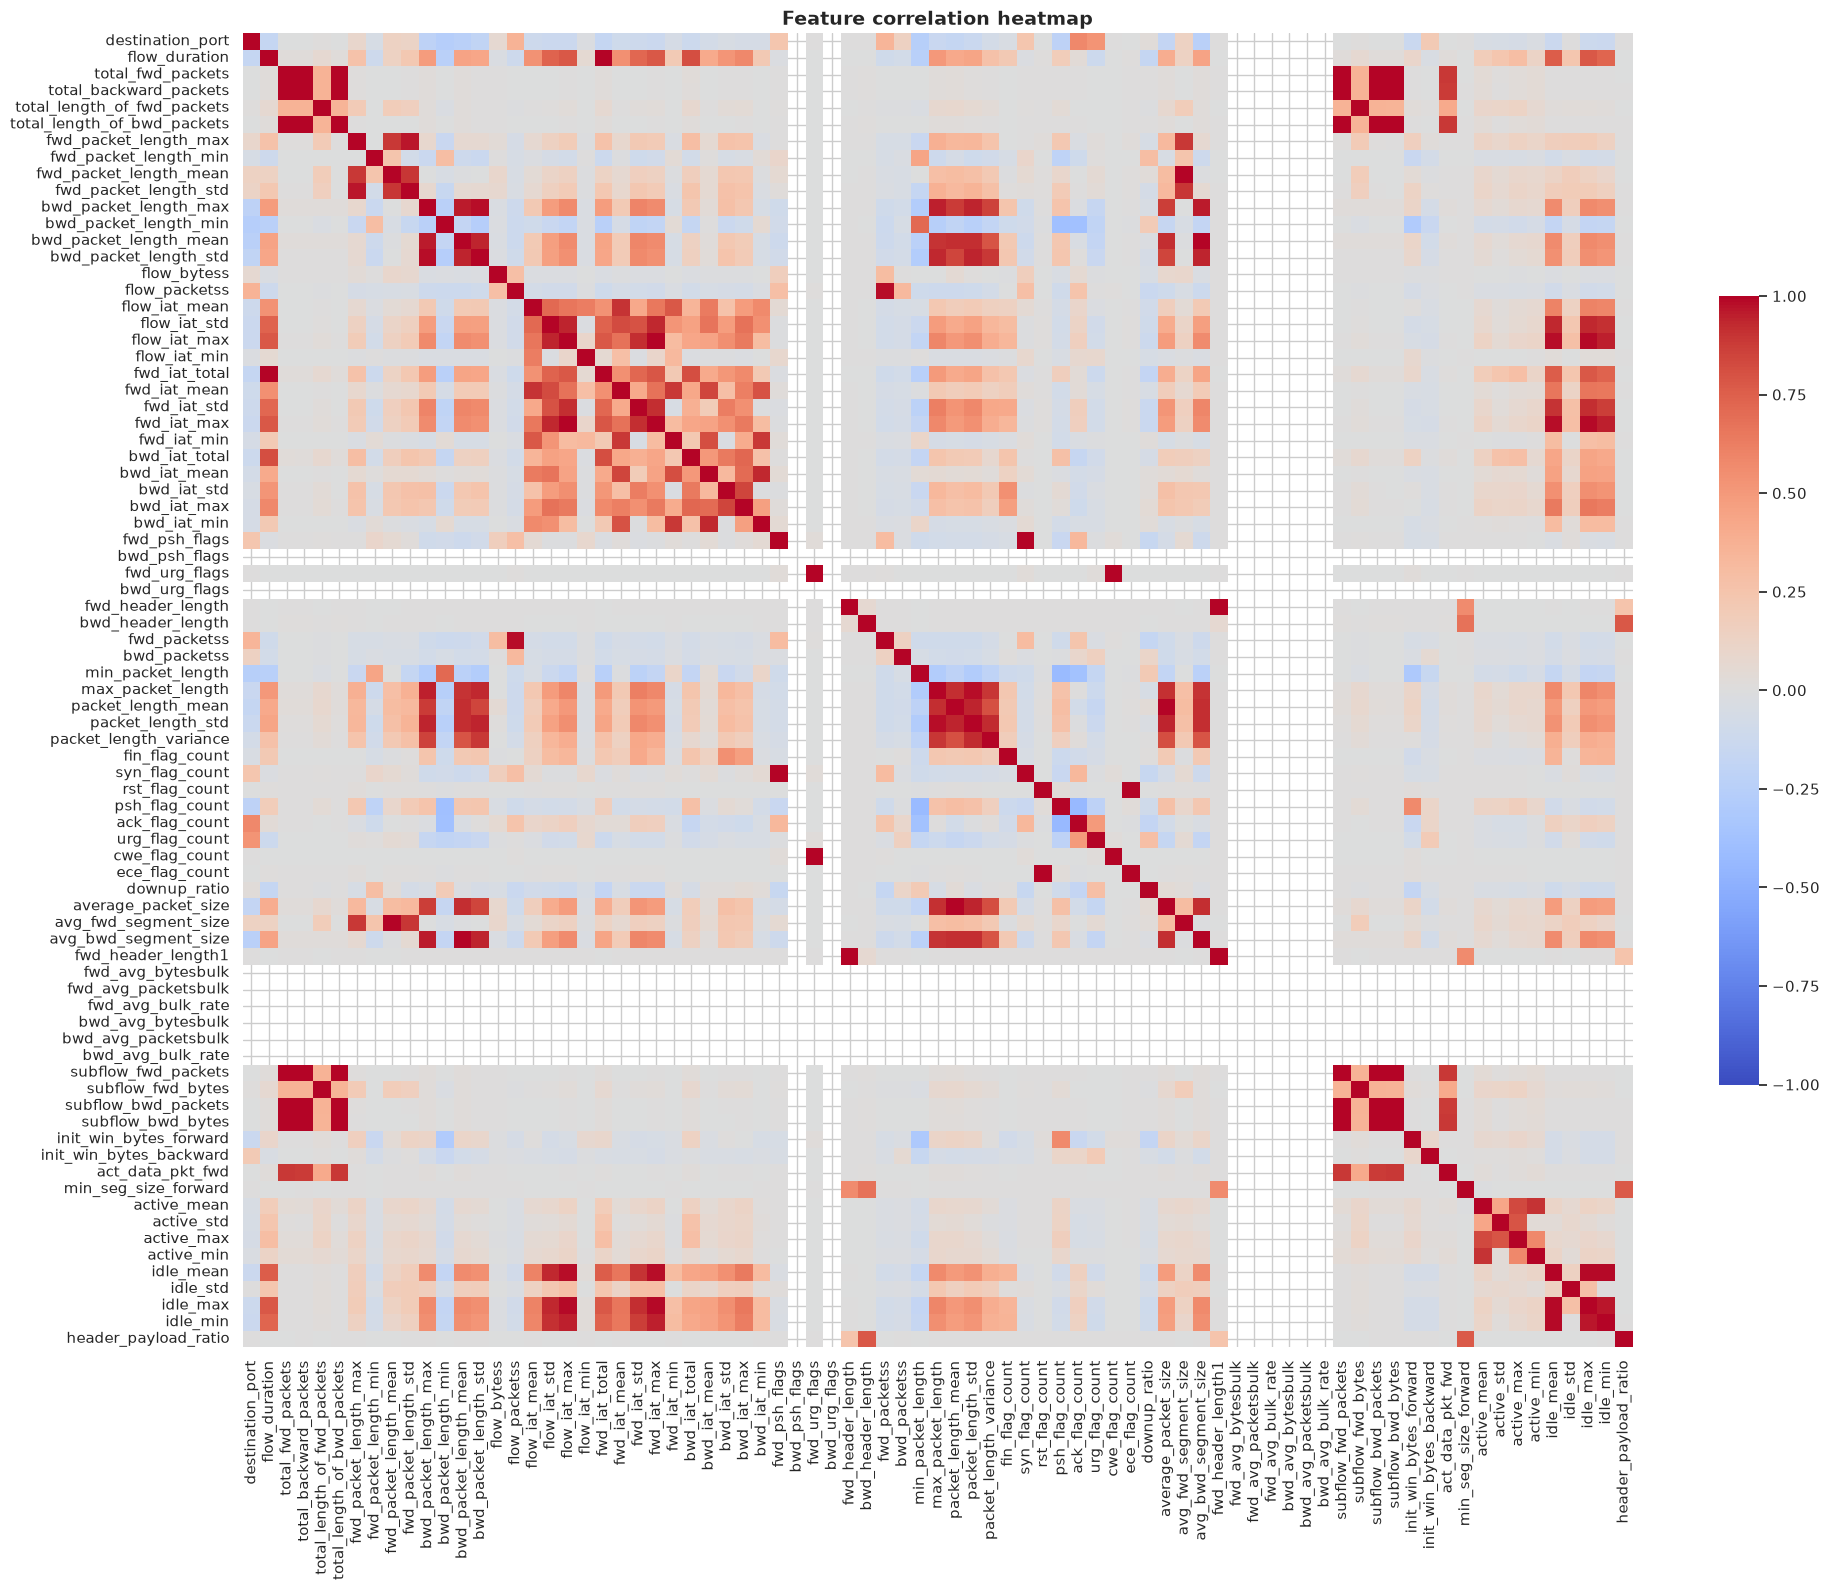

In [17]:
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, cbar_kws={"shrink": 0.6})
plt.title("Feature correlation heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "figures", "correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()


In [18]:
# Actionable follow-up: which specific pairs are highly correlated?
threshold = 0.9
pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) >= threshold:
            pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

high_corr = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation"])
high_corr = high_corr.sort_values("correlation", key=abs, ascending=False)
print(f"{len(high_corr)} feature pairs with |correlation| >= {threshold}")
high_corr.head(20)


71 feature pairs with |correlation| >= 0.9


,feature_1,feature_2,correlation
3,total_fwd_packets,subflow_fwd_packets,1.000
50,fwd_urg_flags,cwe_flag_count,1.000
26,bwd_packet_length_mean,avg_bwd_segment_size,1.000
15,fwd_packet_length_mean,avg_fwd_segment_size,1.000
13,total_length_of_bwd_packets,subflow_bwd_bytes,1.000
10,total_length_of_fwd_packets,subflow_fwd_bytes,1.000
8,total_backward_packets,subflow_bwd_packets,1.000
51,fwd_header_length,fwd_header_length1,1.000
49,fwd_psh_flags,syn_flag_count,1.000
64,subflow_fwd_packets,subflow_bwd_packets,0.999


**Observation.** 71 of the 3,081 possible feature pairs exceed |r| = 0.9.
Nearly all of the strongest ones (r = 1.000) are the same quantity measured
two ways rather than a coincidental relationship: `total_fwd_packets` vs.
`subflow_fwd_packets`, `fwd_packet_length_mean` vs. `avg_fwd_segment_size`,
`total_length_of_bwd_packets` vs. `subflow_bwd_bytes`, and (a genuine data
quirk rather than a naming duplicate) `fwd_header_length` vs.
`fwd_header_length1`, which CICFlowMeter appears to emit twice under
slightly different names. `fwd_urg_flags` vs. `cwe_flag_count` is also a
perfect duplicate in this cleaned data. These are exactly the kind of pairs
that silently double-count in Euclidean-distance-based methods, so this
list feeds directly into `04_Clustering.ipynb`'s correlation-pruning step
(dropping one column per highly-correlated pair before PCA); classification
and regression keep all columns since tree-based/regularized models handle
redundant features far better than distance-based clustering does.

### Quick check: does `destination_port` leak the label?

`destination_port` is deliberately *not* dropped as an identifier column
(see `src/preprocessing.py`) -- it's a real behavioral signal (well-known
service ports vs. ephemeral ones), but also a known shortcut-learning risk:
a model could learn "port 21/22 -> Brute Force" without learning any actual
traffic behavior, which would look like strong performance but generalize
poorly to attacks on non-standard ports. The correlation heatmap above
doesn't show this well since `destination_port`'s relationship with the
(categorical) label isn't linear/numeric. Checking directly instead:

In [19]:
def _top_port(s):
    return s.value_counts().idxmax()

def _top_port_share(s):
    vc = s.value_counts()
    return round(100 * vc.iloc[0] / len(s), 1)

port_by_label = df_clean.groupby(label_col)["destination_port"].agg(
    top_port=_top_port, top_port_share=_top_port_share
).sort_values("top_port_share", ascending=False)
port_by_label


,top_port,top_port_share
label,,
DDoS,80,100.0
DoS Hulk,80,100.0
DoS GoldenEye,80,100.0
DoS Slowhttptest,80,100.0
DoS slowloris,80,100.0
Heartbleed,444,100.0
FTP-Patator,21,100.0
Web Attack ï¿½ Sql Injection,80,100.0
Web Attack ï¿½ Brute Force,80,100.0


**Observation -- this is a real leakage risk, not a hypothetical one.** 11
of the 15 classes are **100% concentrated on a single port**: every DoS/DDoS
variant and both Web Attack subtypes sit entirely on port 80, FTP-Patator
entirely on 21, SSH-Patator entirely on 22, and Heartbleed/Infiltration
entirely on 444. A model could hit very high accuracy on those classes by
memorizing a port-to-label lookup table without learning any real traffic
behavior. Two results confirm the check is measuring something real rather
than an artifact: **PortScan is only 0.4%** concentrated on its top port
(it touches many ports by definition, so no single port dominates -- exactly
as expected) and **BENIGN is only 41.9%** concentrated (legitimate traffic
is naturally spread across services). This is flagged here, not fixed here
-- `destination_port` is kept as a real behavioral feature (see
`src/preprocessing.py`), and the classification notebook's feature
importance ranking should be checked against this table: if `destination_port`
dominates it, the "possible mistakes" section there recommends retraining
without it as a robustness check.

## 11. Important observations

- **Dataset size.** 2,830,743 raw rows merged from 8 day-files -> 2,520,798
  after cleaning (79 raw columns; 80 after feature engineering) -- a 10.95%
  reduction, of which duplicate rows (307,078) are the overwhelming
  majority, not corrupted data (only 2,867 rows, 0.10%, had Infinity/NaN).
  That's worth knowing on its own: this dataset's main quality issue is
  redundant rows, not invalid values.
- **Class imbalance.** 190,459.7 : 1 (BENIGN, 2,095,057 rows, vs.
  Heartbleed, 11 rows). BENIGN alone is 83.11%; the three rarest classes
  (Infiltration, Web Attack - Sql Injection, Heartbleed) total 68 rows
  combined. This is severe enough that `02_Classification.ipynb` cannot
  rely on accuracy -- it reports macro-F1 alongside weighted F1 and uses
  `class_weight="balanced"`, stratified sampling, and SMOTE specifically
  because of what's measured here.
- **Cleaning impact.** 2,867 rows (0.10%) had Infinity (from
  `flow_bytes_s`/`flow_packets_s` division-by-zero on zero-duration flows)
  -- small, and consistent with the literature's description of this
  dataset. 307,078 exact duplicate rows (10.85%) were removed, likely an
  artifact of how CICFlowMeter/the capture process logs repeated
  short flows; not investigated further here since a duplicate row can't
  bias a train/test split any more than it would inflate either side
  proportionally, but worth knowing if reproducing these exact row counts.
- **Correlated features.** 71 of 3,081 possible pairs exceed |r| = 0.9,
  almost all the same quantity measured twice (`total_fwd_packets` vs.
  `subflow_fwd_packets`, etc.) rather than coincidence -- see the
  correlation section for the full breakdown. These feed directly into
  `04_Clustering.ipynb`'s correlation-pruning step; classification and
  regression keep all columns.
- **Feature distributions.** Essentially every numeric feature is heavily
  right-skewed (confirmed both in the 5-key-feature `log1p` panel and the
  all-79-feature raw-scale grid) -- a small number of columns
  (`*_avg_bytesbulk`/`*_avg_packetsbulk`/`*_avg_bulk_rate`) are instead
  near-constant. `StandardScaler` (fit on train only) is used throughout
  this project rather than a log transform, since the tree-based models
  that dominate the later comparison tables split on order, not magnitude,
  and are insensitive to this skew.
- **Outliers.** Checked via IQR per column (20-24% flagged on the worst
  columns) but deliberately not removed -- see the dedicated outlier
  section above for why blanket removal would work against detecting the
  rare attack classes this project cares about most.
- **Feature engineering.** One new feature, `header_payload_ratio`, was
  added (see dedicated section above) and validated visually: the most
  extreme value in a 6,000-row stratified sample belongs to a
  DoS Slowhttptest flow, matching that attack's known "minimal payload,
  connection held open" behavior.
- **Destination port.** Confirmed to be a real leakage risk, not a
  hypothetical one: 11 of 15 classes sit 100% on one port (DoS/DDoS/Web
  Attack variants on 80, FTP-Patator on 21, SSH-Patator on 22,
  Heartbleed/Infiltration on 444), while PortScan (0.4%) and BENIGN
  (41.9%) are appropriately spread out -- confirming the check itself is
  sound. `destination_port` is kept as a feature (it's real signal), but
  `02_Classification.ipynb`'s feature-importance ranking should be
  checked against this table, and the port-dropped robustness check
  mentioned there is worth actually running if it dominates.


## 12. Summary & handoff to the modeling notebooks

This notebook's job was to load, clean, explore, and enrich the raw
CICIDS2017 data once so `02_Classification.ipynb`, `03_Regression.ipynb`,
and `04_Clustering.ipynb` never have to repeat that work or risk cleaning
it differently. Concretely, it hands off `data/processed/cleaned_dataset.csv`
(2,520,798 rows x 80 columns, including the engineered `header_payload_ratio`)
and three findings that directly shape decisions in those notebooks:
the 190,459.7:1 class imbalance (-> `class_weight`, stratified sampling,
SMOTE, macro-F1 in classification), the 71 highly-correlated feature pairs
(-> correlation pruning before clustering's PCA step), and the
`destination_port` leakage risk (-> the robustness check flagged in both
the classification and regression notebooks' final summaries).
